In [1]:
import os
!pip -q install wfdb

BASE = '/content/Group_7_ECG_Project'
for d in ['dataset','results','graphs']:
    os.makedirs(f'{BASE}/{d}', exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.0 MB/s eta 0:00:00


In [4]:
import wfdb
DATA = f'{BASE}/dataset/mitdb'
wfdb.dl_database('mitdb', dl_dir=DATA)

records = wfdb.get_record_list('mitdb')
print(len(records), 'records')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [5]:
import wfdb, os

# 1. folder e file gulo ache kina
files = os.listdir(DATA)
print(len(files), 'files in folder')

# 2. record 100 er signal info
rec = wfdb.rdrecord(f'{DATA}/100')
print('Sampling rate (fs):', rec.fs)
print('Leads             :', rec.sig_name)
print('Signal shape      :', rec.p_signal.shape)
print('Duration          : %.1f min' % (rec.sig_len / rec.fs / 60))
print('Units             :', rec.units)

# 3. record 100 er annotation
ann = wfdb.rdann(f'{DATA}/100', 'atr')
print('First 10 positions:', ann.sample[:10])
print('First 10 symbols  :', ann.symbol[:10])

144 files in folder
Sampling rate (fs): 360
Leads             : ['MLII', 'V5']
Signal shape      : (650000, 2)
Duration          : 30.1 min
Units             : ['mV', 'mV']
First 10 positions: [  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 symbols  : ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


In [6]:
from collections import Counter

# Step 4: record 100 e kon symbol koto bar ache
ann = wfdb.rdann(f'{DATA}/100', 'atr')
print(Counter(ann.symbol))

# Step 5: label definition
BEAT   = set('NLReJjAaSVEF/fQ')   # shudhu real beat symbol
NORMAL = set('NLRej')             # AAMI class N

def to_binary(sym):
    return 0 if sym in NORMAL else 1    # 0 = normal, 1 = abnormal

beats = [s for s in ann.symbol if s in BEAT]
labels = [to_binary(s) for s in beats]
print('Total beats :', len(beats))
print('Normal      :', labels.count(0))
print('Abnormal    :', labels.count(1))

Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})
Total beats : 2273
Normal      : 2239
Abnormal    : 34


In [7]:
BEAT   = set('NLReJjAaSVEF/fQ')   # shudhu real beat symbol
NORMAL = set('NLRej')

def to_binary(sym):
    return 0 if sym in NORMAL else 1    # 0 = normal, 1 = abnormal

ann = wfdb.rdann(f'{DATA}/100', 'atr')
beats = [s for s in ann.symbol if s in BEAT]
labels = [to_binary(s) for s in beats]
print('Total beats :', len(beats))
print('Normal      :', labels.count(0))
print('Abnormal    :', labels.count(1))

Total beats : 2273
Normal      : 2239
Abnormal    : 34


Records used : 44
Total beats  : 100733
Normal       : 90125
Abnormal     : 10608
Abnormal %  : 10.5
N    74546.0
L     8075.0
R     7259.0
V     6903.0
A     2546.0
F      803.0
j      229.0
a      150.0
E      106.0
J       83.0
e       16.0
Q       15.0
S        2.0
f        0.0
/        0.0
dtype: float64


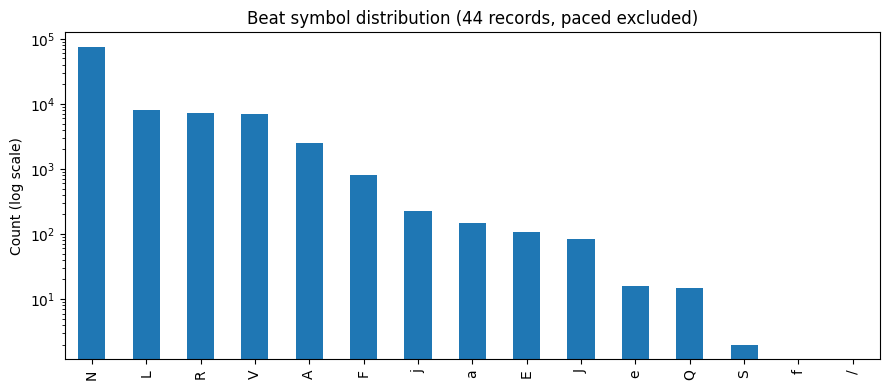

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

records = wfdb.get_record_list('mitdb')
paced = ['102', '104', '107', '217']

rows = []
for r in records:
    a = wfdb.rdann(f'{DATA}/{r}', 'atr')
    syms = [x for x in a.symbol if x in BEAT]
    c = Counter(syms)
    normal = sum(v for k, v in c.items() if k in NORMAL)
    rows.append({'record': r, 'paced_record': r in paced,
                 'total_beats': len(syms), 'normal': normal,
                 'abnormal': len(syms) - normal, **c})

df = pd.DataFrame(rows).fillna(0)
df.to_csv(f'{BASE}/results/dataset_stats_per_record.csv', index=False)

# total (paced record 4 ta bad diye)
use = df[~df['paced_record']]
tot_n, tot_a = use['normal'].sum(), use['abnormal'].sum()
print('Records used :', len(use))
print('Total beats  :', int(tot_n + tot_a))
print('Normal       :', int(tot_n))
print('Abnormal     :', int(tot_a))
print('Abnormal %%  : %.1f' % (100 * tot_a / (tot_n + tot_a)))

# symbol-wise count chart (log scale, karon N onek beshi)
sym_cols = [c for c in df.columns if c not in
            ('record', 'paced_record', 'total_beats', 'normal', 'abnormal')]
counts = use[sym_cols].sum().sort_values(ascending=False)
print(counts)

plt.figure(figsize=(9, 4))
counts.plot(kind='bar', logy=True)
plt.title('Beat symbol distribution (44 records, paced excluded)')
plt.ylabel('Count (log scale)')
plt.tight_layout()
plt.savefig(f'{BASE}/graphs/class_distribution.png', dpi=200)
plt.show()

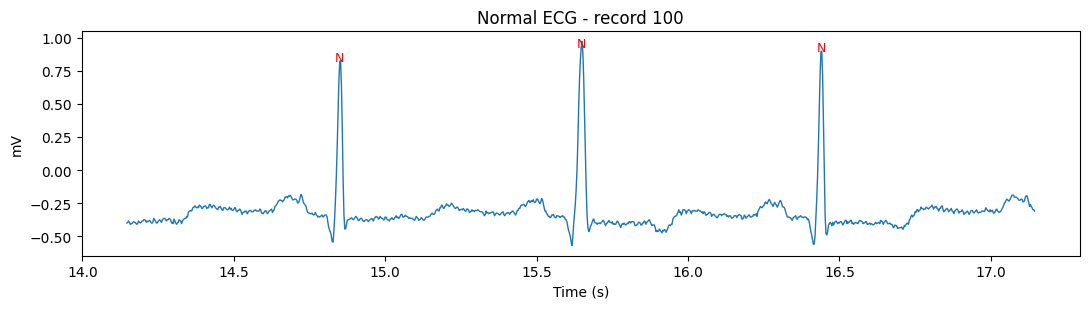

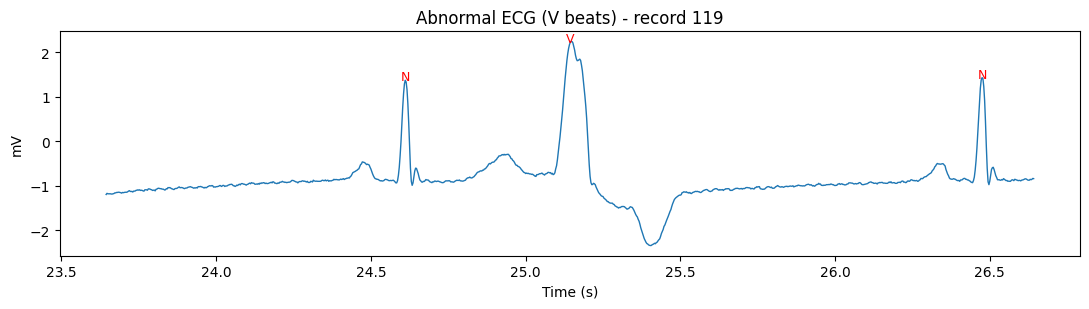

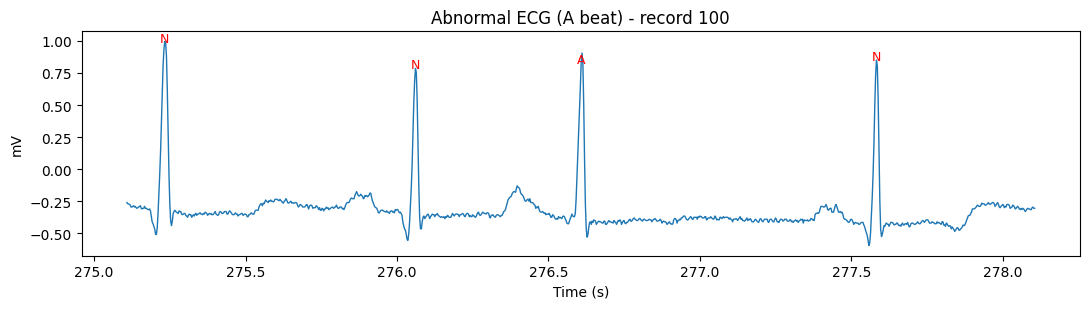

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_window(rec_name, center, label, fname, half=540):   # 3 second (360 Hz)
    rec = wfdb.rdrecord(f'{DATA}/{rec_name}')
    ann = wfdb.rdann(f'{DATA}/{rec_name}', 'atr')
    s0, s1 = max(0, center - half), center + half
    t = np.arange(s0, s1) / rec.fs
    plt.figure(figsize=(11, 3.2))
    plt.plot(t, rec.p_signal[s0:s1, 0], lw=1)
    for i, sym in zip(ann.sample, ann.symbol):
        if s0 <= i < s1 and sym in BEAT:
            plt.annotate(sym, (i / rec.fs, rec.p_signal[i, 0]),
                         color='red', fontsize=9, ha='center')
    plt.title(f'{label} - record {rec_name}')
    plt.xlabel('Time (s)'); plt.ylabel('mV')
    plt.tight_layout()
    plt.savefig(f'{BASE}/graphs/{fname}', dpi=200)
    plt.show()

# 1. Normal ECG (record 100)
a = wfdb.rdann(f'{DATA}/100', 'atr')
plot_window('100', a.sample[20], 'Normal ECG', 'ecg_normal.png')

# 2. Abnormal ECG: ventricular (V) beat, record 119
a = wfdb.rdann(f'{DATA}/119', 'atr')
idx = [i for i, x in zip(a.sample, a.symbol) if x == 'V'][5]
plot_window('119', idx, 'Abnormal ECG (V beats)', 'ecg_abnormal_V.png')

# 3. Abnormal ECG: atrial (A) beat, record 100
a = wfdb.rdann(f'{DATA}/100', 'atr')
idx = [i for i, x in zip(a.sample, a.symbol) if x == 'A'][3]
plot_window('100', idx, 'Abnormal ECG (A beat)', 'ecg_abnormal_A.png')

In [10]:
import shutil

readme = f"""# Dataset README - Group 7 ECG Project

## Source
MIT-BIH Arrhythmia Database, PhysioNet (https://physionet.org/content/mitdb/1.0.0/).
Downloaded with the WFDB Python package (wfdb.dl_database).

## Folder structure
dataset/mitdb/ has 48 records, each with 3 files:
- .dat = ECG signal, .hea = header (sampling rate, leads, gain), .atr = beat annotations
Total files: {len(os.listdir(DATA))}

## Signal information
- Sampling rate: 360 Hz
- Leads: MLII (channel 0) and V5 (channel 1) in record 100
- Record length: about 30 min (650,000 samples per record)
- Recommended lead: channel 0 (MLII)

## Labels
Annotation symbols are placed at each R peak. Non-beat symbols (like '+') are ignored.
- Normal (label 0): N, L, R, e, j (AAMI class N)
- Abnormal (label 1): A, a, J, S, V, E, F, /, f, Q

## Dataset statistics (paced records excluded)
- Records used: {len(use)} (excluded paced records: {', '.join(paced)})
- Total beats: {int(tot_n + tot_a)}
- Normal: {int(tot_n)}
- Abnormal: {int(tot_a)} ({100 * tot_a / (tot_n + tot_a):.1f}%)

Beat symbol counts:
{counts.astype(int).to_string()}

Per-record counts: results/dataset_stats_per_record.csv

## Known issues
- Class imbalance: normal beats are much more than abnormal beats.
- Split must be record-wise (patient-wise) so beats from the same record are not in both train and test.
- Model output is a classification result, not a clinical diagnosis.

## Files from Member 1
- graphs/class_distribution.png, ecg_normal.png, ecg_abnormal_V.png, ecg_abnormal_A.png
- results/dataset_stats_per_record.csv
"""

with open(f'{BASE}/dataset/README.md', 'w') as f:
    f.write(readme)
print(readme)

# README + CSV + graph ekshathe zip kore download
shutil.copy(f'{BASE}/dataset/README.md', f'{BASE}/results/README.md')
shutil.make_archive('/content/Member1_handover', 'zip', BASE, 'results')
shutil.make_archive('/content/Member1_graphs', 'zip', BASE, 'graphs')

from google.colab import files
files.download('/content/Member1_handover.zip')
files.download('/content/Member1_graphs.zip')

# Dataset README - Group 7 ECG Project

## Source
MIT-BIH Arrhythmia Database, PhysioNet (https://physionet.org/content/mitdb/1.0.0/).
Downloaded with the WFDB Python package (wfdb.dl_database).

## Folder structure
dataset/mitdb/ has 48 records, each with 3 files:
- .dat = ECG signal, .hea = header (sampling rate, leads, gain), .atr = beat annotations
Total files: 144

## Signal information
- Sampling rate: 360 Hz
- Leads: MLII (channel 0) and V5 (channel 1) in record 100
- Record length: about 30 min (650,000 samples per record)
- Recommended lead: channel 0 (MLII)

## Labels
Annotation symbols are placed at each R peak. Non-beat symbols (like '+') are ignored.
- Normal (label 0): N, L, R, e, j (AAMI class N)
- Abnormal (label 1): A, a, J, S, V, E, F, /, f, Q

## Dataset statistics (paced records excluded)
- Records used: 44 (excluded paced records: 102, 104, 107, 217)
- Total beats: 100733
- Normal: 90125
- Abnormal: 10608 (10.5%)

Beat symbol counts:
N    74546
L     8075
R     725

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>